In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2

print("Libraries loaded successfully")


Libraries loaded successfully


In [27]:
conn = psycopg2.connect(
    host="localhost",
    database="instacard",
    user="postgres",
    password="postgres"
)

# Data load karo
orders_df = pd.read_sql("SELECT * FROM orders", conn)
print("Data loaded successfully")

C:\Users\ganesh\AppData\Local\Temp\ipykernel_10320\1266798719.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders_df = pd.read_sql("SELECT * FROM orders", conn)


Data loaded successfully


In [28]:
print("Shape:", orders_df.shape)
print("\nColumns:", orders_df.columns.tolist())
orders_df.head()

Shape: (3421083, 7)

Columns: ['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,3233544,6646,prior,11,0,8,30.0
1,1840220,6646,prior,12,0,21,14.0
2,1896475,6646,prior,13,6,7,13.0
3,2191809,6646,prior,14,3,9,30.0
4,2939654,6646,prior,15,0,15,11.0


In [29]:
# Basic information
print("Shape:", orders_df.shape)
print("\nData Types:")
print(orders_df.dtypes)
print("\nNull Values:")
print(orders_df.isnull().sum())
print("\nBasic Statistics:")
orders_df.describe()

Shape: (3421083, 7)

Data Types:
order_id                    int64
user_id                     int64
eval_set                      str
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object

Null Values:
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

Basic Statistics:


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.214874e+06
mean,1.710542e+06,1.029782e+05,1.715486e+01,2.776219e+00,1.345202e+01,1.111484e+01
std,9.875817e+05,5.953372e+04,1.773316e+01,2.046829e+00,4.226088e+00,9.206737e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.552715e+05,5.139400e+04,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00
50%,1.710542e+06,1.026890e+05,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00
75%,2.565812e+06,1.543850e+05,2.300000e+01,5.000000e+00,1.600000e+01,1.500000e+01
max,3.421083e+06,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01


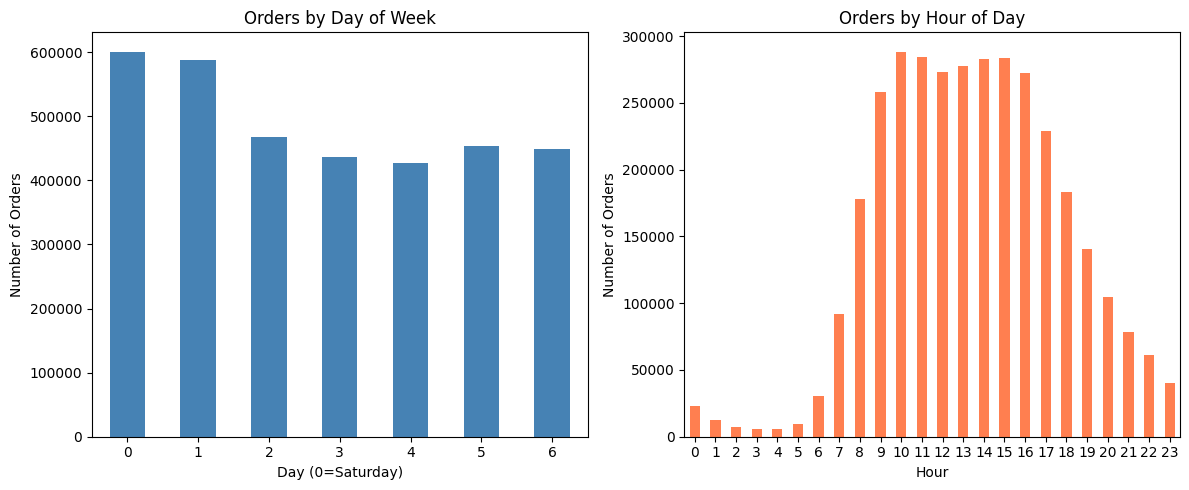

Chart saved!


In [30]:
# Order frequency distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
orders_df['order_dow'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Orders by Day of Week')
plt.xlabel('Day (0=Saturday)')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
orders_df['order_hour_of_day'].value_counts().sort_index().plot(kind='bar', color='coral')
plt.title('Orders by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('../notebooks/01_order_patterns.png', dpi=150)
plt.show()
print("Chart saved!")

## Finding 1: Order Patterns

- **Peak day:** Saturday (Day 0) with 600,905 orders — weekend grocery planning confirmed
- **Peak hours:** 10am-3pm — online shoppers plan ahead during daytime
- **Store insight:** Unlike physical stores where evening rush dominates, 
  online grocery peaks midday — suggesting advance planning behavior

In [31]:
# Load required data for RFM
orders_rfm = pd.read_sql("""
    SELECT 
        user_id,
        COUNT(*) as frequency,
        MAX(order_number) as max_order,
        AVG(days_since_prior_order) as avg_days_between_orders
    FROM orders
    WHERE days_since_prior_order IS NOT NULL
    GROUP BY user_id
""", conn)

print("RFM data shape:", orders_rfm.shape)
orders_rfm.head()

C:\Users\ganesh\AppData\Local\Temp\ipykernel_10320\1613137038.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders_rfm = pd.read_sql("""


RFM data shape: (206209, 4)


,user_id,frequency,max_order,avg_days_between_orders
0,1,10,11,19.000000
1,2,14,15,16.285714
2,3,12,13,12.000000
3,4,5,6,17.000000
4,5,4,5,11.500000


In [32]:
# RFM Scoring — 1 to 5 scale
orders_rfm['frequency_score'] = pd.qcut(
    orders_rfm['frequency'], 
    q=5, 
    labels=[1, 2, 3, 4, 5]
)

orders_rfm['recency_score'] = pd.qcut(
    orders_rfm['avg_days_between_orders'], 
    q=5, 
    labels=[5, 4, 3, 2, 1]  # Lower days = better = higher score
)

# RFM Total Score
orders_rfm['rfm_score'] = (
    orders_rfm['frequency_score'].astype(int) + 
    orders_rfm['recency_score'].astype(int)
)

# Segment labels
def rfm_segment(score):
    if score >= 8:
        return 'Champions'
    elif score >= 6:
        return 'Loyal Customers'
    elif score >= 4:
        return 'Potential Loyalists'
    else:
        return 'At Risk'

orders_rfm['segment'] = orders_rfm['rfm_score'].apply(rfm_segment)

print(orders_rfm['segment'].value_counts())

segment
Champions              61103
Loyal Customers        51933
Potential Loyalists    50610
At Risk                42563
Name: count, dtype: int64


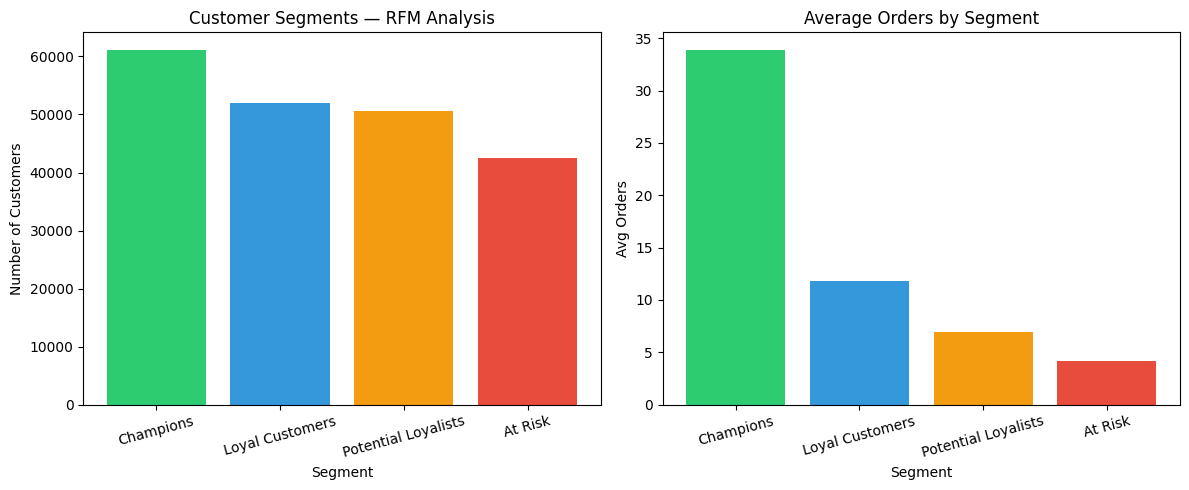

RFM chart saved!


In [33]:
# RFM Segment Distribution
plt.figure(figsize=(12, 5))

# Plot 1 - Segment count
plt.subplot(1, 2, 1)
segment_counts = orders_rfm['segment'].value_counts()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
plt.bar(segment_counts.index, segment_counts.values, color=colors)
plt.title('Customer Segments — RFM Analysis')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)

# Plot 2 - Average frequency by segment
plt.subplot(1, 2, 2)
seg_freq = orders_rfm.groupby('segment')['frequency'].mean().sort_values(ascending=False)
plt.bar(seg_freq.index, seg_freq.values, color=colors)
plt.title('Average Orders by Segment')
plt.xlabel('Segment')
plt.ylabel('Avg Orders')
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('../notebooks/02_rfm_segments.png', dpi=150)
plt.show()
print("RFM chart saved!")

## Finding 2: RFM Customer Segmentation

- **Champions (61,103):** Highest frequency, shortest reorder gap — VIP customers
- **Loyal Customers (51,933):** Regular buyers — retention focus
- **Potential Loyalists (50,610):** Moderate frequency — can be converted with promotions
- **At Risk (42,563):** Declining order frequency — need immediate re-engagement

**Store insight:** 29% customers are Champions — significantly higher than typical 
retail benchmark of 15-20%. Instacart's subscription model drives loyalty.